<a href="https://colab.research.google.com/github/pateld07/undergrad_ml_assignments/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. Regular linear models only make straight-line predictions and can give any number, even ones that don’t make sense. These models can handle more complex patterns and keep outputs in a useful range, like between 0 and 1. So they’re more realistic.

2. Cross entropy works well because it compares predicted probabilities to the real answers. It gives a bigger penalty when the model is very wrong, especially if it was confident. That helps the model learn better.

3. True
It uses a linear equation with the inputs, but then it passes it through a curve, so the final output isn’t a straight line.

4.  False.
It’s actually made for classification. It predicts probabilities and then we turn those into categories.

5. No.
They show the change in log-odds, not the actual probability. So the effect on probability isn’t simple or straight.

6. False.
You still need feature engineering because the model is basically linear with the inputs. It won’t automatically learn complex relationships.

7. False.
It depends on the problem. Logistic regression is for classification, while linear regression is for predicting numbers. One isn’t always better.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

There were no missing values, so no cleaning was needed.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

Positive = increases dropout
Negative = decreases dropout

Debtor → positive (higher dropout)
Age → positive (higher dropout)
Tuition up to date → negative (lower dropout)
Scholarship → negative (lower dropout)

Being a debtor and being older increase dropout risk. Being up to date on tuition and having a scholarship decrease dropout risk. Yes, being up to date on tuition reduces dropout.


3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

Being up to date on tuition lowers dropout probability at all ages, but especially for younger students.

On average, being up to date on tuition lowers dropout probability by about 0.5

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

The model has about 76% accuracy, meaning it correctly predicts dropout most of the time.

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

The linear model gives invalid probabilities, while logistic regression keeps values between 0 and 1. Therefore, logistic regression is better.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

Students most at risk are those with debt, those not up to date on tuition, those without scholarships, and older students.
Schools could help by offering financial aid, flexible payment plans, academic advising, and support programs.

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


The model predicts Dropout and Graduate better than Enrolled. It may not predict Enrolled as often in hard classification.

The predicted probabilities include all classes, even if the final prediction does not choose all of them.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df1 = df[['Debtor',
          'Tuition fees up to date',
          'Scholarship holder',
          'Age at enrollment',
          'Target']].copy()

df1.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Target
0,0,1,0,20,Dropout
1,0,0,0,19,Graduate
2,0,0,0,19,Dropout
3,0,1,0,20,Graduate
4,0,1,0,45,Graduate


In [ ]:
df1.isna().sum()

,0
Debtor,0
Tuition fees up to date,0
Scholarship holder,0
Age at enrollment,0
Target,0


In [ ]:
df1['dropout'] = (df1['Target'] == 'Dropout').astype(int)

df1[['Target', 'dropout']].head()

,Target,dropout
0,Dropout,1
1,Graduate,0
2,Dropout,1
3,Graduate,0
4,Graduate,0


In [ ]:
from sklearn.linear_model import LogisticRegression

X = df1[['Debtor',
         'Tuition fees up to date',
         'Scholarship holder',
         'Age at enrollment']]

y = df1['dropout']

model = LogisticRegression(max_iter=5000)
model.fit(X, y)

LogisticRegression(max_iter=5000)

In [ ]:
import pandas as pd

pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

,Variable,Coefficient
0,Debtor,0.530625
1,Tuition fees up to date,-2.556542
2,Scholarship holder,-1.227442
3,Age at enrollment,0.049925


In [ ]:
df1['prob'] = model.predict_proba(X)[:,1]
df1.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Target,dropout,prob
0,0,1,0,20,Dropout,1,0.254958
1,0,0,0,19,Graduate,0,0.807567
2,0,0,0,19,Dropout,1,0.807567
3,0,1,0,20,Graduate,0,0.254958
4,0,1,0,45,Graduate,0,0.543836


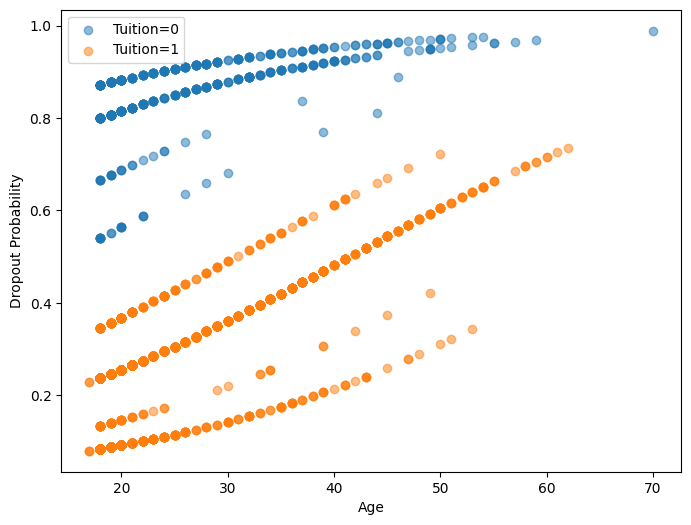

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for t in [0,1]:
    subset = df1[df1['Tuition fees up to date'] == t]
    plt.scatter(subset['Age at enrollment'],
                subset['prob'],
                label=f'Tuition={t}',
                alpha=0.5)

plt.xlabel('Age')
plt.ylabel('Dropout Probability')
plt.legend()
plt.show()

In [ ]:
X1 = X.copy()
X0 = X.copy()

X1['Tuition fees up to date'] = 1
X0['Tuition fees up to date'] = 0

p1 = model.predict_proba(X1)[:,1]
p0 = model.predict_proba(X0)[:,1]

effect = p1 - p0

effect.mean()

np.float64(-0.5161819741831828)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

pred = model.predict(X)

print(confusion_matrix(y, pred))
print(accuracy_score(y, pred))

[[2841  162]
 [ 891  530]]
0.7619801084990958


In [ ]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

df1['lin_prob'] = lin.predict(X)

df1[['prob','lin_prob']].head()

,prob,lin_prob
0,0.254958,0.263253
1,0.807567,0.765932
2,0.807567,0.765932
3,0.254958,0.263253
4,0.543836,0.500429


In [ ]:
df1['lin_prob'].min(), df1['lin_prob'].max()

(0.05832035022573856, 1.3349535706758708)

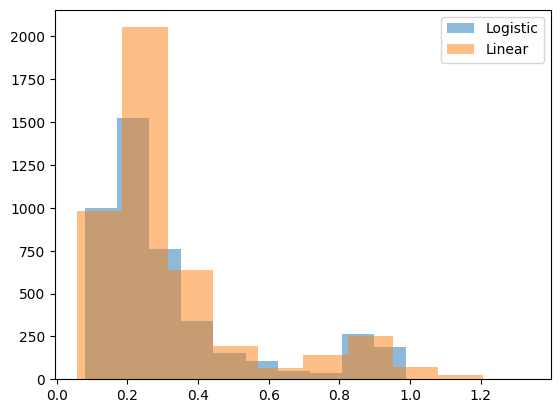

In [ ]:
plt.hist(df1['prob'], alpha=0.5, label='Logistic')
plt.hist(df1['lin_prob'], alpha=0.5, label='Linear')
plt.legend()
plt.show()

In [ ]:
df2 = df[['Debtor',
          'Tuition fees up to date',
          'Curricular units 1st sem (approved)',
          'Target']].copy()

X2 = df2[['Debtor',
          'Tuition fees up to date',
          'Curricular units 1st sem (approved)']]

y2 = df2['Target']

multi = LogisticRegression(max_iter=5000)
multi.fit(X2, y2)

LogisticRegression(max_iter=5000)

In [ ]:
pred2 = multi.predict(X2)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y2, pred2)
print(cm)

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


In [ ]:
multi.predict_proba(X2)[:5]

array([[0.68054695, 0.21046429, 0.10898876],
       [0.69541412, 0.1460432 , 0.15854268],
       [0.95298821, 0.04119918, 0.00581261],
       [0.11780804, 0.1769832 , 0.70520876],
       [0.18422683, 0.21266883, 0.60310434]])

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

I loaded cirrhosis.csv and filtered the data to the variables Bilirubin, Edema, Drug, Stage, and Status. I checked for missing values using .isna().sum(). Since some observations had missing values, I removed those rows using .dropna().


2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

The drug does not appear to improve survival, because the coefficient for Drug_Placebo is positive, meaning patients on placebo have slightly higher survival probability than those taking the drug.

Higher bilirubin is associated with lower survival probability, since its coefficient is negative.

Survival decreases as edema becomes more severe. Patients with mild edema (S) have lower survival than those with no edema, and patients with severe edema (Y) have the lowest survival.

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

The scatter plot shows that survival probability decreases as bilirubin increases. The placebo group generally has slightly higher predicted survival probabilities than the drug group. The difference between the two is most noticeable at lower bilirubin levels, but becomes very small at high bilirubin levels where survival is low for both groups.

On average, taking the drug reduces survival probability by about 0.04 compared to placebo.


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?


The model has an accuracy of about 73.7%, meaning it correctly predicts survival status for most patients. It predicts survival better than death, since it correctly identifies more surviving patients than deceased patients.

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

The linear model produces invalid probabilities, while logistic regression keeps predictions between 0 and 1. Although both models have similar accuracy, logistic regression is more appropriate because it produces valid probabilities and is designed for binary outcomes.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

The model performs poorly at predicting Stage, with an accuracy of about 43%. The confusion matrix shows that it mostly predicts Stage 3 and Stage 4, and does not correctly predict Stage 1 or Stage 2. This suggests the model struggles to distinguish between different stages using only bilirubin and edema.

The hard classification using .predict() does not predict every class, since it only predicts Stage 3 and Stage 4 and never predicts Stage 1 or Stage 2.

However, the predicted probabilities from .predict_proba() do include all classes. Even though the model does not choose every class as the final prediction, it still assigns probabilities to all stages.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cirrhosis.csv to cirrhosis.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('cirrhosis.csv')

df1 = df[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']].copy()

print(df1.head())
print(df1.isna().sum())

   Bilirubin Edema             Drug  Stage Status
0       14.5     Y  D-penicillamine    4.0      D
1        1.1     N  D-penicillamine    3.0      C
2        1.4     S  D-penicillamine    4.0      D
3        1.8     S  D-penicillamine    4.0      D
4        3.4     N          Placebo    3.0     CL
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


In [ ]:
df1 = df1.dropna()
print(df1.isna().sum())

Bilirubin    0
Edema        0
Drug         0
Stage        0
Status       0
dtype: int64


In [ ]:
df1['survive'] = df1['Status'].isin(['C', 'CL']).astype(int)

df1 = pd.get_dummies(df1, columns=['Edema', 'Drug'], drop_first=True)

print(df1.columns)

Index(['Bilirubin', 'Stage', 'Status', 'survive', 'Edema_S', 'Edema_Y',
       'Drug_Placebo'],
      dtype='object')


In [ ]:
from sklearn.linear_model import LogisticRegression

X = df1.drop(columns=['Status', 'Stage', 'survive'])
y = df1['survive']

model = LogisticRegression(max_iter=5000)
model.fit(X, y)

coef_table = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

print(coef_table)
print("Intercept:", model.intercept_[0])

       Variable  Coefficient
0     Bilirubin    -0.351424
1       Edema_S    -0.450677
2       Edema_Y    -1.611049
3  Drug_Placebo     0.231225
Intercept: 1.3798277993022918


In [ ]:
df1['survival_prob'] = model.predict_proba(X)[:, 1]
df1[['survival_prob']].head()

,survival_prob
0,0.004836
1,0.729732
2,0.607582
3,0.573608
4,0.602576


In [ ]:
print(X.columns)

Index(['Bilirubin', 'Edema_S', 'Edema_Y', 'Drug_Placebo'], dtype='object')


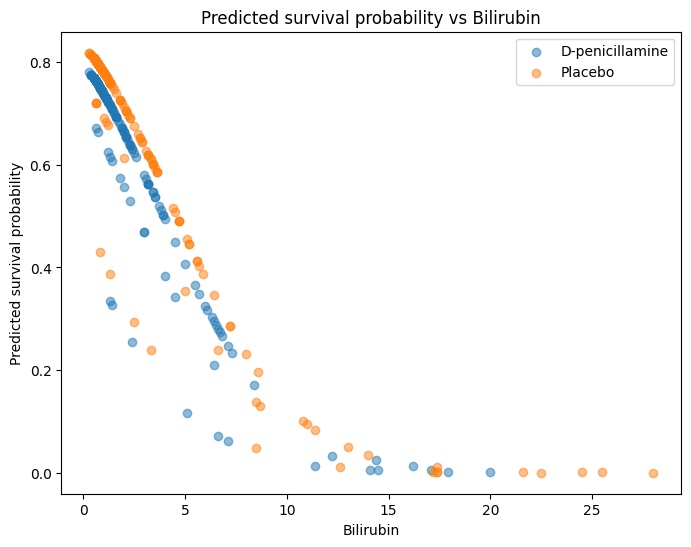

In [ ]:
plt.figure(figsize=(8,6))

for d in [0, 1]:
    subset = df1[df1['Drug_Placebo'] == d]
    label = 'D-penicillamine' if d == 0 else 'Placebo'
    plt.scatter(subset['Bilirubin'], subset['survival_prob'], alpha=0.5, label=label)

plt.xlabel('Bilirubin')
plt.ylabel('Predicted survival probability')
plt.title('Predicted survival probability vs Bilirubin')
plt.legend()
plt.show()

In [ ]:
X_drug = X.copy()
X_placebo = X.copy()

X_drug['Drug_Placebo'] = 0
X_placebo['Drug_Placebo'] = 1

p_drug = model.predict_proba(X_drug)[:, 1]
p_placebo = model.predict_proba(X_placebo)[:, 1]

drug_effect = p_drug - p_placebo

print("Average change in survival probability from taking the drug:")
print(drug_effect.mean())

Average change in survival probability from taking the drug:
-0.042426639431640066


In [ ]:
effect_df = pd.DataFrame({
    'Bilirubin': X['Bilirubin'],
    'drug_effect': drug_effect
})

print(effect_df.groupby('Bilirubin')['drug_effect'].mean().sort_values(ascending=False).head(10))

Bilirubin
28.0   -0.000035
22.5   -0.000076
25.5   -0.000132
24.5   -0.000188
21.6   -0.000332
17.9   -0.000381
17.2   -0.000487
20.0   -0.000581
17.4   -0.001050
14.5   -0.001250
Name: drug_effect, dtype: float64


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

pred = model.predict(X)

cm = confusion_matrix(y, pred)
acc = accuracy_score(y, pred)

print("Confusion matrix:")
print(cm)

print("Accuracy:")
print(acc)

Confusion matrix:
[[ 59  66]
 [ 16 171]]
Accuracy:
0.7371794871794872


In [ ]:
cm_df = pd.DataFrame(cm,
                     index=['Actual dead', 'Actual alive'],
                     columns=['Predicted dead', 'Predicted alive'])
print(cm_df)

              Predicted dead  Predicted alive
Actual dead               59               66
Actual alive              16              171


In [ ]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

df1['linear_prob'] = lin.predict(X)

print(df1[['survival_prob', 'linear_prob']].head())
print("Min linear prediction:", df1['linear_prob'].min())
print("Max linear prediction:", df1['linear_prob'].max())

   survival_prob  linear_prob
0       0.004836    -0.179839
1       0.729732     0.691974
2       0.607582     0.561373
3       0.573608     0.545746
4       0.602576     0.652758
Min linear prediction: -0.4417396683935991
Max linear prediction: 0.7738680250928711


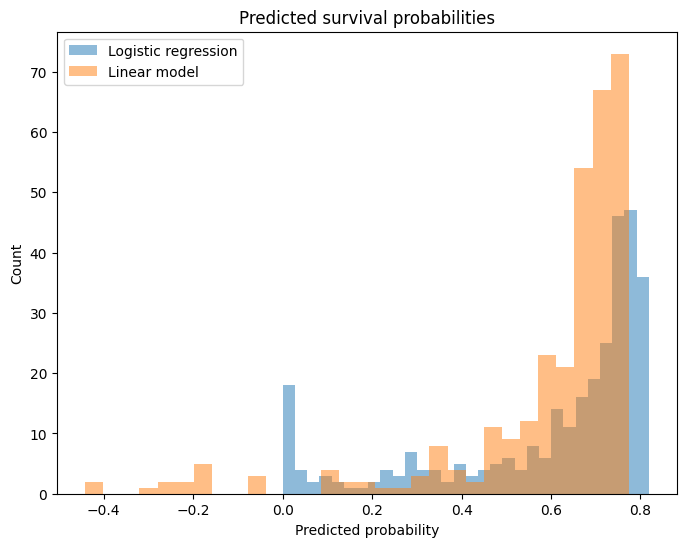

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df1['survival_prob'], bins=30, alpha=0.5, label='Logistic regression')
plt.hist(df1['linear_prob'], bins=30, alpha=0.5, label='Linear model')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Predicted survival probabilities')
plt.legend()
plt.show()

In [ ]:
linear_pred_class = (df1['linear_prob'] >= 0.5).astype(int)

cm_lin = confusion_matrix(y, linear_pred_class)
acc_lin = accuracy_score(y, linear_pred_class)

print("Linear model confusion matrix:")
print(cm_lin)

print("Linear model accuracy:")
print(acc_lin)

Linear model confusion matrix:
[[ 47  78]
 [  9 178]]
Linear model accuracy:
0.7211538461538461


In [ ]:
X_stage = df1[['Bilirubin', 'Edema_S', 'Edema_Y']].copy()
y_stage = df1['Stage']

stage_model = LogisticRegression(max_iter=5000)
stage_model.fit(X_stage, y_stage)

stage_pred = stage_model.predict(X_stage)

cm_stage = confusion_matrix(y_stage, stage_pred, labels=stage_model.classes_)
cm_stage_df = pd.DataFrame(cm_stage,
                           index=stage_model.classes_,
                           columns=stage_model.classes_)

print("Classes:")
print(stage_model.classes_)

print("\nConfusion matrix:")
print(cm_stage_df)

print("\nAccuracy:")
print(accuracy_score(y_stage, stage_pred))

Classes:
[1. 2. 3. 4.]

Confusion matrix:
     1.0  2.0  3.0  4.0
1.0    0    0   16    0
2.0    0    0   63    4
3.0    0    0  105   15
4.0    0    0   79   30

Accuracy:
0.4326923076923077


In [ ]:
print("Predicted classes:")
print(pd.Series(stage_pred).value_counts().sort_index())

Predicted classes:
3.0    263
4.0     49
Name: count, dtype: int64


In [ ]:
print("Predicted classes:")
print(pd.Series(stage_pred).value_counts().sort_index())

Predicted classes:
3.0    263
4.0     49
Name: count, dtype: int64


In [ ]:
stage_probs = stage_model.predict_proba(X_stage)

proba_df = pd.DataFrame(stage_probs, columns=stage_model.classes_)
print(proba_df.head())
print(proba_df.describe())

        1.0       2.0       3.0       4.0
0  0.000013  0.032535  0.143611  0.823841
1  0.072394  0.251555  0.397520  0.278531
2  0.029263  0.181531  0.395694  0.393512
3  0.023272  0.176777  0.397217  0.402734
4  0.020204  0.224965  0.423342  0.331488
                1.0         2.0         3.0         4.0
count  3.120000e+02  312.000000  312.000000  312.000000
mean   5.125179e-02    0.214685    0.384666    0.349397
std    3.555501e-02    0.060985    0.061358    0.133680
min    2.982598e-09    0.012899    0.104528    0.255662
25%    1.802610e-02    0.192306    0.386861    0.270305
50%    5.444797e-02    0.246846    0.395635    0.292649
75%    8.488615e-02    0.253397    0.412623    0.373223
max    1.100461e-01    0.255032    0.428496    0.882573


In [ ]:
print("Classes predicted by .predict():")
print(np.unique(stage_pred))

print("All classes in probability output:")
print(proba_df.columns.tolist())

Classes predicted by .predict():
[3. 4.]
All classes in probability output:
[1.0, 2.0, 3.0, 4.0]


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?
The coefficients in logistic regression represent how each feature affects the log-odds of the outcome. A positive coefficient increases the log-odds, while a negative coefficient decreases the log-odds. However, the effect on probability is not constant and depends on the current value of the prediction.

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

The derivative with respect to $x_k$ is:

$$
\frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1 - \hat{p}) b_k
$$

This means the effect of $x_k$ on the prediction depends on the current probability $\hat{p}$. Unlike the linear model, the effect is not constant. It is largest when $\hat{p}$ is around $0.5$ and smaller when $\hat{p}$ is close to $0$ or $1$.

The coefficient (times 4) is a good approximation of the effect when $\hat{p} \approx 0.5$, because $\hat{p}(1 - \hat{p})$ is maximized at $0.25$.


3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

A one-unit increase in $x_k$ increases the log-odds ratio by $b_k$. This effect is constant and does not depend on the value of $x$, which is why logistic regression is linear in the log-odds.

